Based on Jackson Kang's [implementation](https://github.com/Jackson-Kang/Pytorch-VAE-tutorial).
You need `torchvision`: 

```bash
pip install torchvision==0.22.1  --index-url https://download.pytorch.org/whl/cu118 # from home 2060
```

In [1]:
import torch
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda")

# Dataset and dataloader

In [2]:
ls data

MNIST/


In [3]:
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torchvision import datasets


training_data = datasets.MNIST(
    root="data",
    train=True,
    download=False,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=False,
    transform=ToTensor()
)

batch_size = 512
train_loader = DataLoader(dataset=training_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(dataset=test_data,  batch_size=batch_size, shuffle=False)

training data shape: torch.Size([60000, 28, 28])
example pic 666


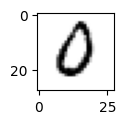

In [4]:
print(f"training data shape: {training_data.data.shape}")
print(f"example pic {(_idx := 666)}")
plt.figure(figsize=(1,1)); plt.imshow(training_data.data[_idx], cmap="Greys"); plt.show()

# Model

In [5]:
import torch.nn as nn


class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.FC_input = nn.Linear(input_dim, hidden_dim)
        self.FC_input2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_mean = nn.Linear(hidden_dim, latent_dim)
        self.FC_var = nn.Linear(hidden_dim, latent_dim)
        self.Leaky_ReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        h_ = self.Leaky_ReLU(self.FC_input(x))
        h_ = self.Leaky_ReLU(self.FC_input2(h_))
        mean= self.FC_mean(h_)
        log_var = self.FC_var(h_)
        return mean, log_var

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.FC_hidden = nn.Linear(latent_dim, hidden_dim)
        self.FC_hidden2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_output = nn.Linear(hidden_dim, output_dim)
        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        h = self.LeakyReLU(self.FC_hidden(x))
        h = self.LeakyReLU(self.FC_hidden2(h))
        x_hat = torch.sigmoid(self.FC_output(h))
        return x_hat

class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super().__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder

    def reparametrization(self, mean, std):
        epsilon = torch.randn_like(std)
        z = mean + std * epsilon
        return z

    def forward(self, x):
        mean, log_var = self.Encoder(x)
        z = self.reparametrization(mean, torch.exp(0.5 * log_var))
        x_hat = self.Decoder(z)
        return x_hat, mean, log_var

In [6]:
hidden_dim = 400
latent_dim = 64
x_dim = training_data.data.shape[1] * training_data.data.shape[2]
encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=x_dim)
model = Model(Encoder=encoder, Decoder=decoder).to(DEVICE)

# Loss

In [7]:
from torch.optim import Adam

BCE_loss = nn.BCELoss(reduction="sum")

def loss_function(x, x_hat, mean, log_var, beta=1.):
    reproduction_loss = BCE_loss(x_hat, x)
    KLD = - 0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    return (reproduction_loss + beta * KLD) / len(x)

lr = 1e-3
optimizer = Adam(model.parameters(), lr=lr)

# Training

In [8]:
print("Start training VAE..")
model.train()

epochs = 30
for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(x.shape[0], x_dim)
        x = x.to(DEVICE)

        optimizer.zero_grad()
        x_hat, mean, log_var = model(x)
        loss = loss_function(x, x_hat, mean, log_var)

        overall_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f"\tEpoch {epoch + 1} complete. Average Loss: {overall_loss / len(train_loader):.5f}") 
print("Finish!!")

Start training VAE..
	Epoch 1 complete. Average Loss: 218.68557
	Epoch 2 complete. Average Loss: 170.14664
	Epoch 3 complete. Average Loss: 144.42401
	Epoch 4 complete. Average Loss: 130.81088
	Epoch 5 complete. Average Loss: 122.67450
	Epoch 6 complete. Average Loss: 118.26340
	Epoch 7 complete. Average Loss: 115.47483
	Epoch 8 complete. Average Loss: 113.25002
	Epoch 9 complete. Average Loss: 111.65156
	Epoch 10 complete. Average Loss: 110.27345
	Epoch 11 complete. Average Loss: 109.06780
	Epoch 12 complete. Average Loss: 108.06980
	Epoch 13 complete. Average Loss: 107.13994
	Epoch 14 complete. Average Loss: 106.39482
	Epoch 15 complete. Average Loss: 105.77402
	Epoch 16 complete. Average Loss: 105.17587
	Epoch 17 complete. Average Loss: 104.72156
	Epoch 18 complete. Average Loss: 104.21971
	Epoch 19 complete. Average Loss: 103.79905
	Epoch 20 complete. Average Loss: 103.54184
	Epoch 21 complete. Average Loss: 103.20501
	Epoch 22 complete. Average Loss: 102.84619
	Epoch 23 complete. 

# Generation

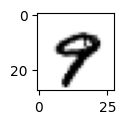

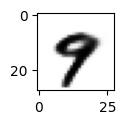

In [9]:
model.eval()
with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
        x = x.view(x.shape[0], x_dim)
        x = x.to(DEVICE)
        y_hat, _, _ = model(x)
        break

_idx = 9
x = x.view(batch_size, 28, 28)
y_hat = y_hat.view(batch_size, 28, 28)
plt.figure(figsize=(1,1)); plt.imshow(x[_idx].cpu().numpy(), cmap="Greys"); plt.show()
plt.figure(figsize=(1,1)); plt.imshow(y_hat[_idx].cpu().numpy(), cmap="Greys"); plt.show()

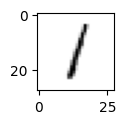

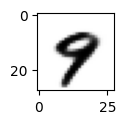

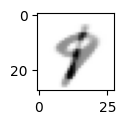

In [20]:
model.eval()
with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
        x = x.view(x.shape[0], x_dim)
        x = x.to(DEVICE)
        y_hat, _, _ = model(x)
        break

_idx1, _idx2 = 2, 9
x = x.view(batch_size, 28, 28)
y_hat = y_hat.view(batch_size, 28, 28)
plt.figure(figsize=(1,1)); plt.imshow(x[_idx1].cpu().numpy(), cmap="Greys"); plt.show()
plt.figure(figsize=(1,1)); plt.imshow(y_hat[_idx2].cpu().numpy(), cmap="Greys"); plt.show()
plt.figure(figsize=(1,1)); plt.imshow((y_hat[_idx1] + y_hat[_idx2]).cpu().numpy(), cmap="Greys"); plt.show()

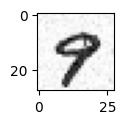

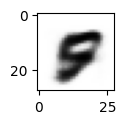

In [22]:
model.eval()
with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
        x = x.view(x.shape[0], x_dim) + torch.abs(torch.randn(x.shape[0], x_dim) * 0.1)
        x = x.to(DEVICE)
        y_hat, _, _ = model(x)
        break

_idx = 9
x = x.view(batch_size, 28, 28)
y_hat = y_hat.view(batch_size, 28, 28)
plt.figure(figsize=(1,1)); plt.imshow(x[_idx].cpu().numpy(), cmap="Greys"); plt.show()
plt.figure(figsize=(1,1)); plt.imshow(y_hat[_idx].cpu().numpy(), cmap="Greys"); plt.show()